# NHANES III Knee X-Ray — KL Grade Labels & Train/Val/Test Split

**Purpose:** Download the NHANES III knee osteoarthritis X-ray data file,
extract Kellgren-Lawrence (KL) grades for left and right knees, cross-reference
with processed PNG files on Google Drive, and produce stratified
`train.csv`, `val.csv`, and `test.csv` splits (70 / 15 / 15).

**Data source:**  
CDC, NHANES III Series 11, No. 11A — Knee Osteoarthritis X-Ray (October 2001)  
URL: `https://wwwn.cdc.gov/nchs/data/nhanes3/11a/xr.dat`  

**KL grade variables (fixed-width columns):**
| Variable | Column | Description |
|---|---|---|
| `SEQN` | 1-5 | Respondent ID |
| `XRPKLR` | 6 | KL grade, right knee |
| `XRPKLL` | 7 | KL grade, left knee |

**Valid grade codes:** 0=Normal, 1=Possible, 2=Definite, 3=Moderate, 4=Severe  
**Excluded codes:** 8=Blank/applicable, 9=Unreadable

---
**Note:** Only Phase 2 (1991–1994) participants have knee X-rays in this release.
SEQN range in the file is approximately 32234–53616.

In [1]:

from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [2]:


import sys, subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'matplotlib'], check=True)
print('Dependencies ready.')

Dependencies ready.


In [ ]:

import re, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

DRIVE_ROOT = Path('/content/drive/MyDrive')
PROJECT    = DRIVE_ROOT / 'Master Thesis'

OUT_DIR   = PROJECT / 'nhanes3' / 'processed'
LABEL_DIR = PROJECT / 'nhanes3'
XR_DAT_URL = 'https://wwwn.cdc.gov/nchs/data/nhanes3/11a/xr.dat'
XR_DAT_LOCAL = Path('/content/xr.dat')

PNG_SUFFIX = 'norm-pct1-99_clahe-2.0_224px'

VAL_FRAC  = 0.15
TEST_FRAC = 0.15

LABEL_DIR.mkdir(parents=True, exist_ok=True)
print(f'OUT_DIR  : {OUT_DIR}')
print(f'LABEL_DIR: {LABEL_DIR}')


OUT_DIR  : /content/drive/MyDrive/nhanes3/processed
LABEL_DIR: /content/drive/MyDrive/nhanes3


In [4]:

if not XR_DAT_LOCAL.exists():
    print(f'Downloading {XR_DAT_URL} ...')
    urllib.request.urlretrieve(XR_DAT_URL, XR_DAT_LOCAL)
    print(f'Saved → {XR_DAT_LOCAL} ({XR_DAT_LOCAL.stat().st_size:,} bytes)')
else:
    print(f'Already exists: {XR_DAT_LOCAL} ({XR_DAT_LOCAL.stat().st_size:,} bytes)')

Saved → /content/xr.dat (75,079 bytes)


In [5]:


colspecs = [(0, 5), (5, 6), (6, 7)]
names    = ['seqn', 'kl_right', 'kl_left']

raw = pd.read_fwf(
    XR_DAT_LOCAL,
    colspecs=colspecs,
    names=names,
    dtype=str,
    header=None,
)

for col in names:
    raw[col] = pd.to_numeric(raw[col].str.strip(), errors='coerce')

raw['seqn'] = raw['seqn'].astype('Int64')

print(f'Total rows read : {len(raw):,}')
print(raw[['kl_right','kl_left']].value_counts(dropna=False).sort_index())

Total rows read : 2,589
kl_right  kl_left
0         0          1126
          1            86
          2            76
          3             3
          4             1
          9             2
1         0            49
          1           118
          2            71
          3             5
          4             1
          9             2
2         0            82
          1            87
          2           394
          3            60
          4             2
          9             7
3         0             8
          1             5
          2            75
          3            57
          4            19
          9             2
4         0             1
          1             1
          2            16
          3            12
          4            21
          9             3
8         8           163
9         0             5
          1             5
          2             8
          3             4
          4             1
          9           

In [6]:


VALID_KL = {0, 1, 2, 3, 4}

rows = []
for _, r in raw.iterrows():
    seqn = r['seqn']
    if pd.isna(seqn):
        continue
    seqn = int(seqn)
    for side, kl_val in [('R', r['kl_right']), ('L', r['kl_left'])]:
        if pd.isna(kl_val) or int(kl_val) not in VALID_KL:
            continue
        filename = f'NHANES3_SEQN{seqn}_{side}_{PNG_SUFFIX}.png'
        rows.append({
            'filename' : filename,
            'seqn'     : seqn,
            'side'     : side,
            'kl_grade' : int(kl_val),
        })

labels_df = pd.DataFrame(rows)
print(f'Label rows (per knee, valid KL only): {len(labels_df):,}')
print('KL grade distribution (all knees):')
print(labels_df['kl_grade'].value_counts().sort_index())

Label rows (per knee, valid KL only): 4,791
KL grade distribution (all knees):
kl_grade
0    2565
1     548
2    1272
3     307
4      99
Name: count, dtype: int64


In [7]:


if not OUT_DIR.exists():
    raise FileNotFoundError(f'Processed PNG directory not found: {OUT_DIR}')

existing_pngs = set(p.name for p in OUT_DIR.glob('*.png'))
print(f'PNGs found on Drive: {len(existing_pngs):,}')

matched = labels_df[labels_df['filename'].isin(existing_pngs)].copy()
print(f'Label rows matched to existing PNGs: {len(matched):,}')

if len(matched) == 0:
    print('\n⚠  No matches found. Either the batch job has not run yet, or the'
          ' OUT_DIR path is wrong. The full labels table is still saved below.')

PNGs found on Drive: 9,810
Label rows matched to existing PNGs: 4,785


In [8]:

full_csv = LABEL_DIR / 'labels_all.csv'
labels_df.to_csv(full_csv, index=False)
print(f'Saved: {full_csv}  ({len(labels_df):,} rows)')

Saved: /content/drive/MyDrive/nhanes3/labels_all.csv  (4,791 rows)


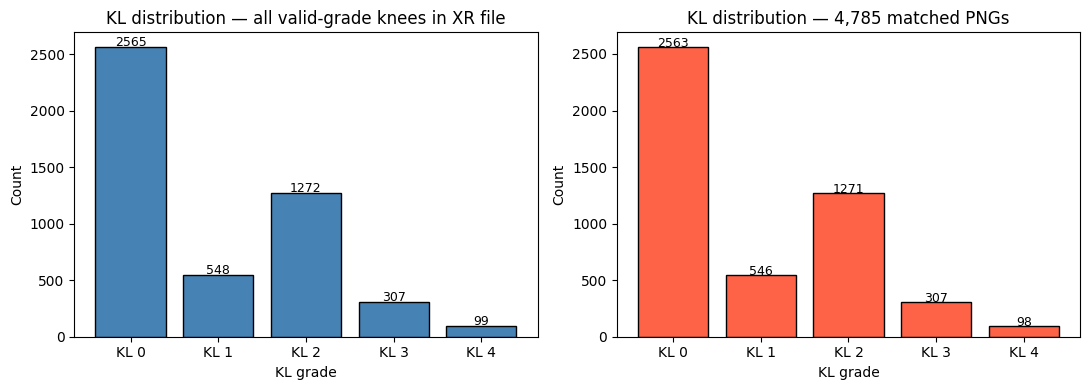

Plot saved: /content/drive/MyDrive/nhanes3/kl_distribution.png


In [9]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

kl_all     = labels_df['kl_grade'].value_counts().sort_index()
kl_matched = matched['kl_grade'].value_counts().sort_index() if len(matched) else pd.Series(dtype=int)

kl_labels  = [f'KL {i}' for i in sorted(kl_all.index)]

axes[0].bar(kl_labels, kl_all.values, color='steelblue', edgecolor='black')
axes[0].set_title('KL distribution — all valid-grade knees in XR file')
axes[0].set_xlabel('KL grade'); axes[0].set_ylabel('Count')
for i, v in enumerate(kl_all.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

if len(kl_matched):
    kl_m_labels = [f'KL {i}' for i in sorted(kl_matched.index)]
    axes[1].bar(kl_m_labels, kl_matched.values, color='tomato', edgecolor='black')
    axes[1].set_title(f'KL distribution — {len(matched):,} matched PNGs')
    axes[1].set_xlabel('KL grade'); axes[1].set_ylabel('Count')
    for i, v in enumerate(kl_matched.values):
        axes[1].text(i, v + 0.2, str(v), ha='center', fontsize=9)
else:
    axes[1].set_visible(False)

plt.tight_layout()
plot_path = LABEL_DIR / 'kl_distribution.png'
plt.savefig(plot_path, dpi=120)
plt.show()
print(f'Plot saved: {plot_path}')

In [10]:


df_split = matched.copy() if len(matched) >= 10 else labels_df.copy()
if len(matched) < 10:
    print('WARNING: Fewer than 10 matched PNGs — splitting full label table.')
    print('Re-run after the batch job has processed more images.')

seqn_strat = (
    df_split.groupby('seqn')['kl_grade']
    .max()
    .reset_index()
    .rename(columns={'kl_grade': 'strat_kl'})
)
n_persons = len(seqn_strat)
print(f'Unique persons (SEQNs): {n_persons:,}')
print('Max-KL distribution per person:')
print(seqn_strat['strat_kl'].value_counts().sort_index())

def _safe_strat(series):
    """Return series for stratification, or None if any class has < 2 samples."""
    if series.value_counts().min() < 2:
        print('Note: A KL class has < 2 persons — using random (non-stratified) split.')
        return None
    return series

trainval_seqns, test_seqns = train_test_split(
    seqn_strat,
    test_size=TEST_FRAC,
    stratify=_safe_strat(seqn_strat['strat_kl']),
    random_state=42,
)

val_frac_of_trainval = VAL_FRAC / (1.0 - TEST_FRAC)
train_seqns, val_seqns = train_test_split(
    trainval_seqns,
    test_size=val_frac_of_trainval,
    stratify=_safe_strat(trainval_seqns['strat_kl']),
    random_state=42,
)

train_df = df_split[df_split['seqn'].isin(train_seqns['seqn'])].copy()
val_df   = df_split[df_split['seqn'].isin(val_seqns['seqn'])].copy()
test_df  = df_split[df_split['seqn'].isin(test_seqns['seqn'])].copy()

assert set(train_df['seqn']).isdisjoint(set(val_df['seqn'])),  'LEAK: train ∩ val!'
assert set(train_df['seqn']).isdisjoint(set(test_df['seqn'])), 'LEAK: train ∩ test!'
assert set(val_df['seqn']).isdisjoint(set(test_df['seqn'])),   'LEAK: val ∩ test!'
print('\n✓ Person-level integrity verified — no SEQN appears in more than one split.')

total = len(df_split)
print(f'\nSplit summary — {n_persons:,} persons → {total:,} knee images:')
print(f'  train: {len(train_seqns):,} persons  →  {len(train_df):,} knees  ({100*len(train_df)/total:.1f}%)')
print(f'  val  : {len(val_seqns):,} persons  →  {len(val_df):,} knees  ({100*len(val_df)/total:.1f}%)')
print(f'  test : {len(test_seqns):,} persons  →  {len(test_df):,} knees  ({100*len(test_df)/total:.1f}%)')

print('\nKL distribution per split (knee images):')
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    dist = df['kl_grade'].value_counts().sort_index().to_dict()
    print(f'  {name:5s}: {dist}')


Unique persons (SEQNs): 2,412
Max-KL distribution per person:
strat_kl
0    1132
1     259
2     725
3     219
4      77
Name: count, dtype: int64

✓ Person-level integrity verified — no SEQN appears in more than one split.

Split summary — 2,412 persons → 4,785 knee images:
  train: 1,688 persons  →  3,350 knees  (70.0%)
  val  : 362 persons  →  717 knees  (15.0%)
  test : 362 persons  →  718 knees  (15.0%)

KL distribution per split (knee images):
  train: {0: 1794, 1: 384, 2: 886, 3: 213, 4: 73}
  val  : {0: 381, 1: 84, 2: 190, 3: 51, 4: 11}
  test : {0: 388, 1: 78, 2: 195, 3: 43, 4: 14}


In [11]:

split_files = {
    'train.csv': train_df,
    'val.csv'  : val_df,
    'test.csv' : test_df,
}

for fname, df in split_files.items():
    out_path = LABEL_DIR / fname
    df.to_csv(out_path, index=False)
    print(f'Saved: {out_path}  ({len(df):,} rows)')

for df, split_name in [(train_df, 'train'), (val_df, 'val'), (test_df, 'test')]:
    df['split'] = split_name

combined = pd.concat([train_df, val_df, test_df], ignore_index=True)
combined_path = LABEL_DIR / 'labels_split.csv'
combined.to_csv(combined_path, index=False)
print(f'\nCombined (with split column): {combined_path}  ({len(combined):,} rows)')
print('\nDone! Files on Drive:')
for f in sorted(LABEL_DIR.glob('*.csv')):
    print(f'  {f.name}  ({f.stat().st_size:,} bytes)')

Saved: /content/drive/MyDrive/nhanes3/train.csv  (3,350 rows)
Saved: /content/drive/MyDrive/nhanes3/val.csv  (717 rows)
Saved: /content/drive/MyDrive/nhanes3/test.csv  (718 rows)

Combined (with split column): /content/drive/MyDrive/nhanes3/labels_split.csv  (4,785 rows)

Done! Files on Drive:
  labels_all.csv  (301,861 bytes)
  labels_split.csv  (328,047 bytes)
  test.csv  (45,262 bytes)
  train.csv  (211,078 bytes)
  val.csv  (45,199 bytes)
